<a href="https://colab.research.google.com/github/tinemyumi/saude-mental-datasus/blob/main/notebooks/4.eda_panorama.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **EDA: Panorama Geral**

## **Objetivo**
Descrever a estrutura e a qualidade do dataset de internações em saúde mental (SIH/SUS - SP, 2015–2025),
gerando uma visão consolidada das variáveis principais e a **Tabela 1** para publicação.

## **Conteúdo**
- 1. Setup
- 2. Carregamento dos Dados
- 3. Qualidade dos Dados
  - 3.1 Valores Nulos
  - 3.2 Valores Duplicados
  - 3.3 Consistências
- 4. Volume Geral
- 5. Cobertura Geográfica
- 6. Distribuição das Variáveis-Chave
- 7. Tabela 1: Características Gerais por Período

## **Histórico de Alterações**
- **Data:** 06.02.2026 | **Autor:** Larissa Tinem


## **1. Setup**

In [ ]:
# Bibliotecas
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

# Google Drive
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
# Paleta e estilo
COLOR1 = '#1B4F72'   # azul escuro
COLOR2 = '#48C9B0'   # verde-azulado
COLOR3 = '#5499C7'   # azul médio
COLORS = [COLOR1, COLOR2, COLOR3]
PALETTE_PERIODO = {
    'Pre-Pandemia' : COLOR1,
    'Pandemia'     : COLOR2,
    'Pos-Pandemia' : COLOR3,
}

plt.rcParams['figure.dpi']      = 120
plt.rcParams['axes.spines.top']  = False
plt.rcParams['axes.spines.right']= False
sns.set_style('whitegrid')

# Ordem canônica dos períodos
ORDEM_PERIODOS = ['Pre-Pandemia', 'Pandemia', 'Pos-Pandemia']

## **2. Carregamento dos Dados**

In [ ]:
# Carregar os arquivos
df_pre = pd.read_parquet('/content/drive/MyDrive/Dataframes/df_sih_sus_sem_tratamento/saude_mental_pre_pandemia.parquet')
df_pan = pd.read_parquet('/content/drive/MyDrive/Dataframes/df_sih_sus_sem_tratamento/saude_mental_pandemia.parquet')
df_pos = pd.read_parquet('/content/drive/MyDrive/Dataframes/df_sih_sus_sem_tratamento/saude_mental_pos_pandemia.parquet')

# Criar a coluna de período para facilitar a comparação posterior
df_pre['periodo'] = 'Pre-Pandemia'
df_pan['periodo'] = 'Pandemia'
df_pos['periodo'] = 'Pos-Pandemia'

# Unir tudo em um único DataFrame
df = pd.concat([df_pre, df_pan, df_pos], ignore_index=True)

del df_pre, df_pan, df_pos

## **3. Qualidade dos Dados**

### **3.1. Valores Nulos**

In [ ]:
df.isnull().sum()

,0
UF_ZI,0
ANO_CMPT,0
MES_CMPT,0
NASC,0
IDADE,0
SEXO,0
RACA_COR,0
ESPEC,0
IDENT,0
MUNIC_RES,0


### **3.2. Valores duplicados**

**Análise Inicial**

- **Quantidade total de linhas:** 1.079.670
- **Quantidade total de internações:** 1.061.744
- **Diferença:** 17.926

A base apresentou aproximadamente 1,7% de registros duplicados, associados a reprocessamentos administrativos, os quais foram removidos para evitar superestimação do número de internações.



In [ ]:
df.duplicated().sum()

np.int64(450)

In [ ]:
# Identificando ~evento~ de uma internação
chave_internacao = [
    'UF_ZI',
    'ANO_CMPT',
    'MUNIC_RES',
    'DT_INTER',
    'DT_SAIDA',
    'DIAG_PRINC',
    'SEXO',
    'IDADE',
    'MORTE'
]

# Elimina duplicatas de acordo com o evento de internação
df_tratado = df.drop_duplicates(subset=chave_internacao)

# Conta o total de internações
total_internacoes = df_tratado.shape[0]
print('Número total de linhas: ', df.shape[0])
print('Número total de internações: ', total_internacoes)
print('Diferença: ', df.shape[0] - df_tratado.shape[0])

Número total de linhas:  1079670
Número total de internações:  1061744
Diferença:  17926


**Interpretação:** queda esperada ao longo dos anos indica melhora no preenchimento, o que impacta a análise de raça: documentar na seção de limitações do artigo.

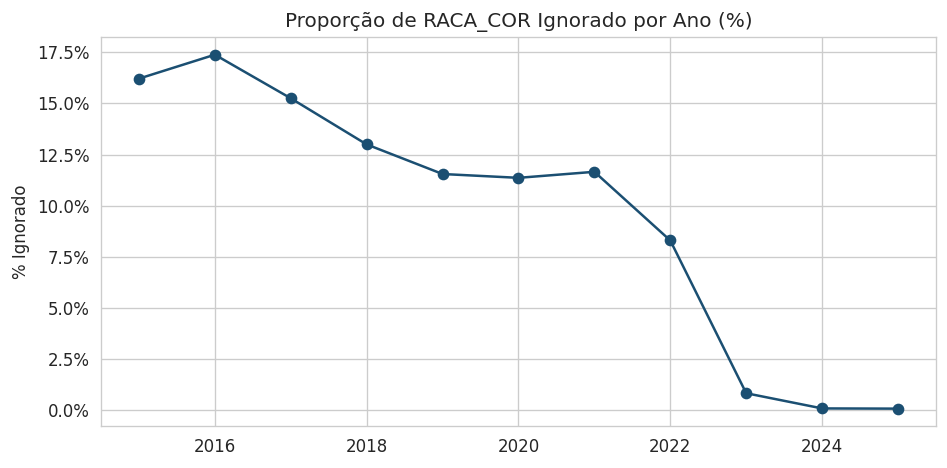

In [ ]:
# Evolução anual do preenchimento de RACA_COR
# Importante para a discussão metodológica do artigo
raca_ignorado = (
    df.assign(ignorado=df['RACA_COR'] == '99')
    .groupby('ANO_CMPT')['ignorado']
    .mean() * 100
)

fig, ax = plt.subplots(figsize=(8, 4))
raca_ignorado.plot(ax=ax, marker='o', color=COLOR1)
ax.set_title('Proporção de RACA_COR Ignorado por Ano (%)')
ax.set_ylabel('% Ignorado')
ax.set_xlabel('')
ax.yaxis.set_major_formatter(mticker.FormatStrFormatter('%.1f%%'))
plt.tight_layout()
plt.show()


### **3.3 Consistência**

In [ ]:
# Verifica valores inesperados nas variáveis categóricas principais
checks = {
    'SEXO'   : ['1', '3'],
    'CAR_INT': ['01', '02'],
    'MORTE'  : ['0', '1'],
    'COMPLEX': ['01', '02', '03'],
}

for col, valores_esperados in checks.items():
    valores_encontrados = df[col].unique().tolist()
    inesperados = [v for v in valores_encontrados if v not in valores_esperados]
    status = '✅' if not inesperados else f'⚠️  {inesperados}'
    print(f'{col:10s} | esperado: {valores_esperados} | {status}')

SEXO       | esperado: ['1', '3'] | ✅
CAR_INT    | esperado: ['01', '02'] | ✅
MORTE      | esperado: ['0', '1'] | ✅
COMPLEX    | esperado: ['01', '02', '03'] | ✅


In [ ]:
# Verifica consistência de datas e idade
print(f'Período coberto    : {df["ANO_CMPT"].min()} – {df["ANO_CMPT"].max()}')
print(f'Idades negativas   : {(df["IDADE"] < 0).sum()}')
print(f'Idades > 120       : {(df["IDADE"] > 120).sum()}')
print(f'DT_SAIDA < DT_INTER: {(df["DT_SAIDA"] < df["DT_INTER"]).sum()}')
print(f'DIAS_PERM < 0      : {(df["DIAS_PERM"] < 0).sum()}')

Período coberto    : 2015 – 2025
Idades negativas   : 0
Idades > 120       : 0
DT_SAIDA < DT_INTER: 0
DIAS_PERM < 0      : 0


## **4. Volume Geral**

**Análise Inicial**


In [ ]:
df['periodo'] = pd.Categorical(
    df['periodo'],
    categories=['Pre-Pandemia','Pandemia','Pos-Pandemia'],
    ordered=True
)

In [ ]:
# Internações por período
vol = df.groupby('periodo', observed=True).size().reset_index(name='internacoes')
vol['pct_total'] = (vol['internacoes'] / vol['internacoes'].sum() * 100).round(1)
print(vol.to_string(index=False))

     periodo  internacoes  pct_total
Pre-Pandemia       556336       51.5
    Pandemia       241285       22.3
Pos-Pandemia       282049       26.1


In [ ]:
# Média mensal por período
media_mensal = (
    df.groupby(['periodo', 'ANO_CMPT', 'MES_CMPT'], observed=True)
    .size()
    .reset_index(name='total_mes')
    .groupby('periodo', observed=True)['total_mes']
    .agg(['mean', 'std', 'median'])
    .round(1)
)
print(media_mensal)

                mean     std  median
periodo                             
Pre-Pandemia  9272.3  1337.7  8657.0
Pandemia      6702.4   589.0  6660.5
Pos-Pandemia  7834.7   358.8  7799.0


In [ ]:
# Variação percentual entre períodos
medias = media_mensal['mean']
print(f'Pré → Pandemia   : {(medias["Pandemia"] / medias["Pre-Pandemia"] - 1) * 100:.1f}%')
print(f'Pandemia → Pós   : {(medias["Pos-Pandemia"] / medias["Pandemia"] - 1) * 100:.1f}%')
print(f'Pré → Pós        : {(medias["Pos-Pandemia"] / medias["Pre-Pandemia"] - 1) * 100:.1f}%')

Pré → Pandemia   : -27.7%
Pandemia → Pós   : 16.9%
Pré → Pós        : -15.5%


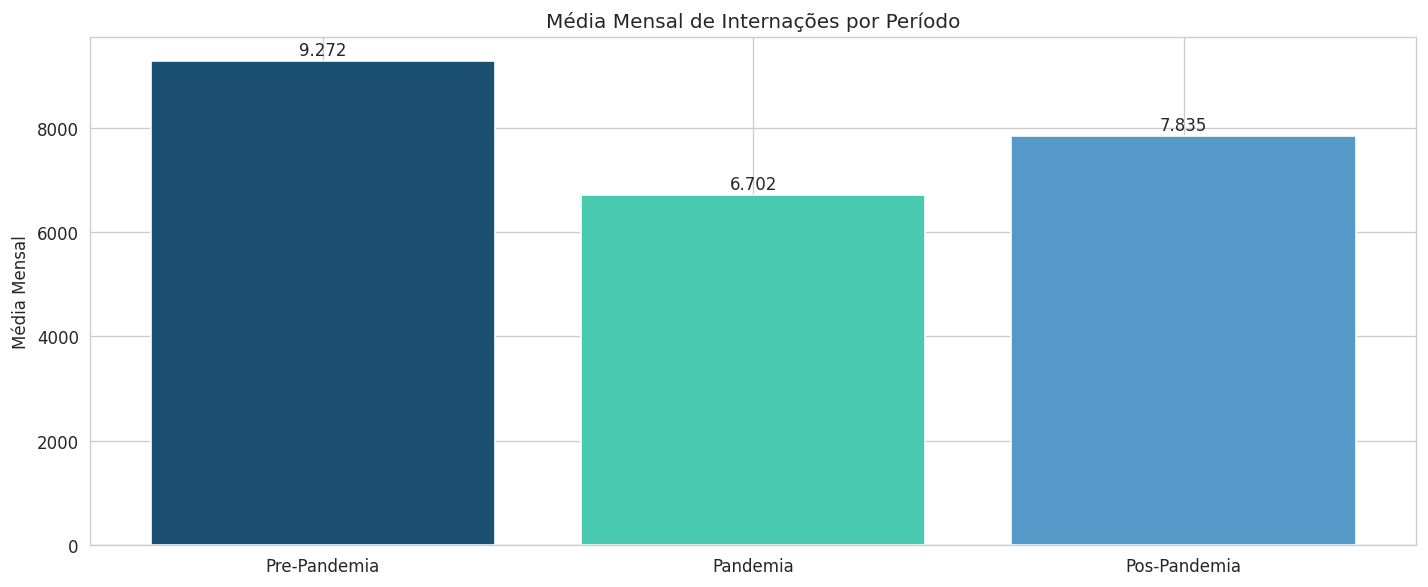

In [ ]:
ordem = ['Pre-Pandemia', 'Pandemia', 'Pos-Pandemia']
media_mensal = media_mensal.reindex(ordem)

fig, ax = plt.subplots(figsize=(12, 5))

bars = ax.bar(
    media_mensal.index,
    media_mensal['mean'],
    color=[PALETTE_PERIODO.get(p, '#999999') for p in media_mensal.index],
    edgecolor='white'
)

for bar in bars:
    h = bar.get_height()
    ax.text(
        bar.get_x() + bar.get_width()/2,
        h + 50,
        f'{h:,.0f}'.replace(',', '.'),
        ha='center',
        va='bottom',
        fontsize=10
    )

ax.set_title('Média Mensal de Internações por Período')
ax.set_ylabel('Média Mensal')

plt.tight_layout()
plt.show()

In [ ]:
# Municípios de residência vs. de internação
n_munic_res = df['MUNIC_RES'].nunique()
n_munic_int = df['MUNIC_MOV'].nunique()

print(f'Municípios de residência : {n_munic_res}')
print(f'Municípios de internação : {n_munic_int}')
print(f'Razão res/int: {n_munic_res / n_munic_int:.1f}x')

Municípios de residência : 1256
Municípios de internação : 332
Razão res/int: 3.8x


In [ ]:
# Municípios com zero internações (vazios assistenciais absolutos)
munic_com_internacao = set(df['MUNIC_MOV'].unique())
munic_com_residentes = set(df['MUNIC_RES'].unique())

vazios_absolutos = munic_com_residentes - munic_com_internacao
print(f'Municípios que geram pacientes, mas não internam: {len(vazios_absolutos)}')
print(f'({len(vazios_absolutos)/len(munic_com_residentes)*100:.1f}% dos municípios de residência)')

Municípios que geram pacientes, mas não internam: 924
(73.6% dos municípios de residência)


## **7. Distribuição das Variáveis-Chave**

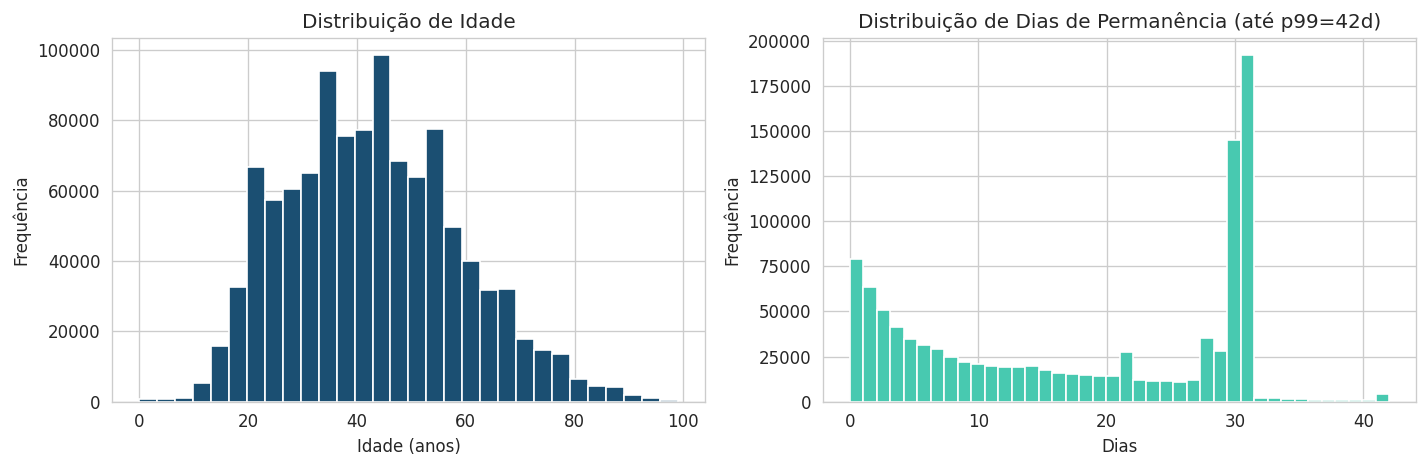

           IDADE  DIAS_PERM
count  1079670.0  1079670.0
mean        43.0       18.0
std         15.9       12.1
min          0.0        0.0
25%         31.0        6.0
50%         42.0       18.0
75%         54.0       30.0
max         99.0      261.0


In [ ]:
# Painel com distribuição das principais variáveis numéricas
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Idade
axes[0].hist(df['IDADE'], bins=30, color=COLOR1, edgecolor='white')
axes[0].set_title('Distribuição de Idade')
axes[0].set_xlabel('Idade (anos)')
axes[0].set_ylabel('Frequência')

# Tempo de permanência (limitado ao percentil 99 para não distorcer)
p99 = df['DIAS_PERM'].quantile(0.99)
axes[1].hist(df[df['DIAS_PERM'] <= p99]['DIAS_PERM'],
             bins=40, color=COLOR2, edgecolor='white')
axes[1].set_title(f'Distribuição de Dias de Permanência (até p99={p99:.0f}d)')
axes[1].set_xlabel('Dias')
axes[1].set_ylabel('Frequência')

plt.tight_layout()
plt.show()

print(df[['IDADE', 'DIAS_PERM']].describe().round(1))

In [ ]:
# Taxa de óbitos geral e por período
df['morte_flag'] = df['MORTE'].astype(str) == '1'

obito_geral = df['morte_flag'].mean() * 100
obito_periodo = df.groupby('periodo', observed=True)['morte_flag'].mean() * 100

print(f'Taxa de óbito geral: {obito_geral:.2f}%')
print('Taxa de óbito por período:')
print(obito_periodo.round(2))

Taxa de óbito geral: 0.29%
Taxa de óbito por período:
periodo
Pre-Pandemia    0.29
Pandemia        0.30
Pos-Pandemia    0.27
Name: morte_flag, dtype: float64


## **8. Tabela 1 — Características Gerais por Período**

Tabela-resumo no formato padrão de publicações epidemiológicas.
Pode ser exportada diretamente para o artigo.

In [ ]:
# Decodificações necessárias para a Tabela 1
df['SEXO_DESC']    = df['SEXO'].map({'1': 'Masculino', '3': 'Feminino'})
df['RACA_DESC']    = df['RACA_COR'].map({
    '01': 'Branca', '02': 'Parda', '03': 'Preta',
    '04': 'Amarela', '05': 'Indígena', '99': 'Ignorado'
})
df['CAR_INT_DESC']  = df['CAR_INT'].map({'01': 'Eletivo', '02': 'Urgência'})
df['evasao']        = df['MUNIC_RES'] != df['MUNIC_MOV']

In [ ]:
def tabela1(grupo):
    return pd.Series({
        'N internações'             : len(grupo),
        'Média mensal'              : round(len(grupo) / grupo['ANO_CMPT'].nunique() / 12, 0),
        'Idade — média (dp)'        : f'{grupo["IDADE"].mean():.1f} ({grupo["IDADE"].std():.1f})',
        'Idade — mediana'           : grupo['IDADE'].median(),
        '% Feminino'               : f'{(grupo["SEXO_DESC"] == "Feminino").mean()*100:.1f}%',
        '% Masculino'              : f'{(grupo["SEXO_DESC"] == "Masculino").mean()*100:.1f}%',
        '% Branca'                 : f'{(grupo["RACA_DESC"] == "Branca").mean()*100:.1f}%',
        '% Parda'                  : f'{(grupo["RACA_DESC"] == "Parda").mean()*100:.1f}%',
        '% Preta'                  : f'{(grupo["RACA_DESC"] == "Preta").mean()*100:.1f}%',
        '% Ignorado (raça)'        : f'{(grupo["RACA_DESC"] == "Ignorado").mean()*100:.1f}%',
        'Dias perm. — média (dp)'  : f'{grupo["DIAS_PERM"].mean():.1f} ({grupo["DIAS_PERM"].std():.1f})',
        'Dias perm. — mediana'     : grupo['DIAS_PERM'].median(),
        '% Urgência'               : f'{(grupo["CAR_INT_DESC"] == "Urgência").mean()*100:.1f}%',
        '% Óbito'                  : f'{grupo["morte_flag"].mean()*100:.2f}%',
        '% Evasão municipal'       : f'{grupo["evasao"].mean()*100:.1f}%',
    })

tabela_1 = df.groupby('periodo', observed=True).apply(tabela1).T
tabela_1['Total'] = df.pipe(tabela1)

tabela_1

/tmp/ipykernel_824/345596584.py:20: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  tabela_1 = df.groupby('periodo', observed=True).apply(tabela1).T


periodo,Pre-Pandemia,Pandemia,Pos-Pandemia,Total
N internações,556336,241285,282049,1079670
Média mensal,9272.0,6702.0,7835.0,8179.0
Idade — média (dp),44.5 (16.3),42.2 (15.8),40.6 (14.9),43.0 (15.9)
Idade — mediana,44.0,41.0,40.0,42.0
% Feminino,37.6%,38.4%,39.0%,38.1%
% Masculino,62.4%,61.6%,61.0%,61.9%
% Branca,54.1%,53.3%,54.9%,54.1%
% Parda,8.7%,9.1%,9.2%,8.9%
% Preta,21.8%,26.6%,34.9%,26.3%
% Ignorado (raça),14.9%,10.4%,0.3%,10.1%


In [ ]:
# Exportar Tabela 1 para CSV (para uso no artigo)
tabela_1.to_csv('/content/drive/MyDrive/Dataframes/tabela1_panorama.csv', sep=';', encoding='utf-8-sig')
print('Tabela 1 exportada com sucesso.')

Tabela 1 exportada com sucesso.
